In this notebook we study grokking for group extensions. We start with a simple example of direct product and a semidirect product.

The setup as usual

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import random

import matplotlib.pyplot as plt

import os
import sys

random.seed(0)
pair_seed = 420

module_path = os.path.abspath(".")
if module_path not in sys.path:
    sys.path.append(module_path)

dtype = torch.float32

############## Use GPU ##############
USE_GPU = True
#####################################
if USE_GPU == True and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print('using device:', device)

using device: cuda


We start with a group $\mathbb{Z}_p \times \mathbb{Z}_2$ and $\mathbb{Z}_p \rtimes \mathbb{Z}_2$

In [8]:
def data_create_prod(p: int, frac: float, device, pair_seed: int):
    X_pairs = torch.cartesian_prod(
        torch.arange(2*p, device=device),
        torch.arange(2*p, device=device)
    )
    Y = (X_pairs[:, 0]%p +X_pairs[:, 1]%p) %p+p*((X_pairs[:, 0]//p+X_pairs[:, 1]//p)%2)
    X = F.one_hot(X_pairs, num_classes=2*p).float()
    X = X.reshape(X.shape[0], -1)

    n = X.shape[0]
    n_train = int(frac * n)

    if pair_seed is None:
        perm = torch.randperm(n, device=device)
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(n, generator=g, device=device)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    return {
        "X_pairs": X_pairs,
        "Y": Y,
        "X_train": X[train_idx],
        "Y_train": Y[train_idx],
        "X_test": X[test_idx],
        "Y_test": Y[test_idx],
        "pairs_train": X_pairs[train_idx],
        "pairs_test": X_pairs[test_idx],
    }

def data_create_semidirectprod(p: int, frac: float, device, pair_seed: int):
    X_pairs = torch.cartesian_prod(
        torch.arange(2*p, device=device),
        torch.arange(2*p, device=device)
    )

    sign = torch.where((X_pairs[:, 0]//p) == 0, 1, -1)
    Y = (X_pairs[:, 0]%p +sign*X_pairs[:, 1]%p) %p+p*((X_pairs[:, 0]//p+X_pairs[:, 1]//p)%2)
    X = F.one_hot(X_pairs, num_classes=2*p).float()
    X = X.reshape(X.shape[0], -1)

    n = X.shape[0]
    n_train = int(frac * n)

    if pair_seed is None:
        perm = torch.randperm(n, device=device)
    else:
        g = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(n, generator=g, device=device)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    return {
        "X_pairs": X_pairs,
        "Y": Y,
        "X_train": X[train_idx],
        "Y_train": Y[train_idx],
        "X_test": X[test_idx],
        "Y_test": Y[test_idx],
        "pairs_train": X_pairs[train_idx],
        "pairs_test": X_pairs[test_idx],
    }

In [11]:
class MLP(nn.Module):
    def __init__(self, in_size, hid_size, out_size):
        super(MLP, self).__init__()

        self.in_size=in_size
        self.hid_size=hid_size
        self.out_size=out_size
        self.fc1=nn.Linear(in_size, hid_size, bias=False)
        self.fc2=nn.Linear(hid_size, out_size, bias=False)
        
        torch.nn.init.normal_(self.fc1.weight, mean=0.0, std=0.25**0.5 / np.power(2*self.hid_size, 1/3)) #### standard initialization
        torch.nn.init.normal_(self.fc2.weight, mean=0.0, std=0.25**0.5 / np.power(2*self.hid_size, 1/3))

    def forward(self, x):
        x = self.fc2( torch.relu(  self.fc1(x)  ) )
        return x


In [22]:
p = 31
frac = 0.3
hid_size = 250
n_epochs = 50000

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)





In [10]:
def train_prod():
    model = MLP(in_size=4*p, hid_size=hid_size, out_size=2*p).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.5) 

    train_losses = torch.empty(n_epochs, device=device)
    test_losses = torch.empty(n_epochs, device=device)
    train_accs = torch.empty(n_epochs, device=device)
    test_accs = torch.empty(n_epochs, device=device)

    data=data_create_prod(p,frac,device, pair_seed=420)
    X_train=data['X_train'].float()
    Y_train=data['Y_train']
    X_test=data['X_test'].float()
    Y_test=data['Y_test']

    for epoch in range(n_epochs):
        model.train()

        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, Y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_train)
            test_logits = model(X_test)

            train_loss = criterion(train_logits, Y_train)
            test_loss = criterion(test_logits, Y_test)

            train_pred = train_logits.argmax(dim=1)
            test_pred = test_logits.argmax(dim=1)

            train_acc = (train_pred == Y_train).float().mean()
            test_acc = (test_pred == Y_test).float().mean()

        train_losses[epoch] = train_loss
        test_losses[epoch] = test_loss
        train_accs[epoch] = train_acc
        test_accs[epoch] = test_acc

        if (epoch + 1) % 2000 == 0:
            print(
                f"Epoch {epoch+1:6d}/{n_epochs} | "
                f"train_loss={train_loss.item():.6f} | "
                f"test_loss={test_loss.item():.6f} | "
                f"train_acc={train_acc.item():.6f} | "
                f"test_acc={test_acc.item():.6f}"
            )
    
    return {'train_loss':train_losses, 'test_losses': test_losses, 'train_accs': train_accs, 'test_accs': test_accs}

def train_semidirprod():

    model = MLP(in_size=4*p, hid_size=hid_size, out_size=2*p).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.5) 

    train_losses = torch.empty(n_epochs, device=device)
    test_losses = torch.empty(n_epochs, device=device)
    train_accs = torch.empty(n_epochs, device=device)
    test_accs = torch.empty(n_epochs, device=device)

    data=data_create_semidirectprod(p,frac,device, pair_seed=420)
    X_train=data['X_train'].float()
    Y_train=data['Y_train']
    X_test=data['X_test'].float()
    Y_test=data['Y_test']

    for epoch in range(n_epochs):
        model.train()

        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, Y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_train)
            test_logits = model(X_test)

            train_loss = criterion(train_logits, Y_train)
            test_loss = criterion(test_logits, Y_test)

            train_pred = train_logits.argmax(dim=1)
            test_pred = test_logits.argmax(dim=1)

            train_acc = (train_pred == Y_train).float().mean()
            test_acc = (test_pred == Y_test).float().mean()

        train_losses[epoch] = train_loss
        test_losses[epoch] = test_loss
        train_accs[epoch] = train_acc
        test_accs[epoch] = test_acc

        if (epoch + 1) % 2000 == 0:
            print(
                f"Epoch {epoch+1:6d}/{n_epochs} | "
                f"train_loss={train_loss.item():.6f} | "
                f"test_loss={test_loss.item():.6f} | "
                f"train_acc={train_acc.item():.6f} | "
                f"test_acc={test_acc.item():.6f}"
            )
    return {'train_loss':train_losses, 'test_losses': test_losses, 'train_accs': train_accs, 'test_accs': test_accs}

In [16]:
@torch.no_grad()
def group_coordinate_metrics(logits, pairs, p, kind="direct"):
    """
    logits: [batch, 2*p]
    pairs:  [batch, 2], where each entry is a token g = a + p*b

    kind: "direct" or "semidirect"
    """

    pred = logits.argmax(dim=1)

    # Decode prediction
    pred_c = pred % p
    pred_d = pred // p

    # Decode inputs
    g = pairs[:, 0]
    h = pairs[:, 1]

    a = g % p
    b = g // p

    ap = h % p
    bp = h // p

    # True multiplication rule
    if kind == "direct":
        factor = torch.ones_like(b)
    elif kind == "semidirect":
        factor = torch.where(b == 0, 1, -1)
    else:
        raise ValueError("kind must be 'direct' or 'semidirect'")

    true_c = (a + factor * ap) % p
    true_d = (b + bp) % 2
    true_y = true_c + p * true_d

    full_acc = (pred == true_y).float().mean()
    Cp_acc = (pred_c == true_c).float().mean()
    C2_acc = (pred_d == true_d).float().mean()

    # Sector accuracies: condition on the left input coset b=0 or b=1
    mask_b0 = (b == 0)
    mask_b1 = (b == 1)

    Cp_acc_b0 = (pred_c[mask_b0] == true_c[mask_b0]).float().mean()
    Cp_acc_b1 = (pred_c[mask_b1] == true_c[mask_b1]).float().mean()

    full_acc_b0 = (pred[mask_b0] == true_y[mask_b0]).float().mean()
    full_acc_b1 = (pred[mask_b1] == true_y[mask_b1]).float().mean()

    return {
        "full_acc": full_acc,
        "Cp_acc": Cp_acc,
        "C2_acc": C2_acc,
        "Cp_acc_b0": Cp_acc_b0,
        "Cp_acc_b1": Cp_acc_b1,
        "full_acc_b0": full_acc_b0,
        "full_acc_b1": full_acc_b1,
    }

In [17]:
def train_group(kind="direct"):
    
    model = MLP(in_size=4*p, hid_size=hid_size, out_size=2*p).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.5)

    train_losses = torch.empty(n_epochs, device=device)
    test_losses = torch.empty(n_epochs, device=device)

    train_full_accs = torch.empty(n_epochs, device=device)
    test_full_accs = torch.empty(n_epochs, device=device)

    train_Cp_accs = torch.empty(n_epochs, device=device)
    test_Cp_accs = torch.empty(n_epochs, device=device)

    train_C2_accs = torch.empty(n_epochs, device=device)
    test_C2_accs = torch.empty(n_epochs, device=device)

    train_Cp_accs_b0 = torch.empty(n_epochs, device=device)
    test_Cp_accs_b0 = torch.empty(n_epochs, device=device)

    train_Cp_accs_b1 = torch.empty(n_epochs, device=device)
    test_Cp_accs_b1 = torch.empty(n_epochs, device=device)

    train_full_accs_b0 = torch.empty(n_epochs, device=device)
    test_full_accs_b0 = torch.empty(n_epochs, device=device)

    train_full_accs_b1 = torch.empty(n_epochs, device=device)
    test_full_accs_b1 = torch.empty(n_epochs, device=device)

    if kind == "direct":
        data = data_create_prod(p, frac, device, pair_seed=420)
    else:
        data = data_create_semidirectprod(p, frac, device, pair_seed=420)

    X_train = data["X_train"].float()
    Y_train = data["Y_train"]
    X_test = data["X_test"].float()
    Y_test = data["Y_test"]

    pairs_train = data["pairs_train"]
    pairs_test = data["pairs_test"]

    for epoch in range(n_epochs):
        model.train()

        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, Y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_train)
            test_logits = model(X_test)

            train_loss = criterion(train_logits, Y_train)
            test_loss = criterion(test_logits, Y_test)

            train_metrics = group_coordinate_metrics(
                train_logits, pairs_train, p, kind=kind
            )
            test_metrics = group_coordinate_metrics(
                test_logits, pairs_test, p, kind=kind
            )

        train_losses[epoch] = train_loss
        test_losses[epoch] = test_loss

        train_full_accs[epoch] = train_metrics["full_acc"]
        test_full_accs[epoch] = test_metrics["full_acc"]

        train_Cp_accs[epoch] = train_metrics["Cp_acc"]
        test_Cp_accs[epoch] = test_metrics["Cp_acc"]

        train_C2_accs[epoch] = train_metrics["C2_acc"]
        test_C2_accs[epoch] = test_metrics["C2_acc"]

        train_Cp_accs_b0[epoch] = train_metrics["Cp_acc_b0"]
        test_Cp_accs_b0[epoch] = test_metrics["Cp_acc_b0"]

        train_Cp_accs_b1[epoch] = train_metrics["Cp_acc_b1"]
        test_Cp_accs_b1[epoch] = test_metrics["Cp_acc_b1"]

        train_full_accs_b0[epoch] = train_metrics["full_acc_b0"]
        test_full_accs_b0[epoch] = test_metrics["full_acc_b0"]

        train_full_accs_b1[epoch] = train_metrics["full_acc_b1"]
        test_full_accs_b1[epoch] = test_metrics["full_acc_b1"]

        if (epoch + 1) % 2000 == 0:
            print(
                f"{kind:10s} | "
                f"Epoch {epoch+1:6d}/{n_epochs} | "
                f"train_loss={train_loss.item():.6f} | "
                f"test_loss={test_loss.item():.6f} | "
                f"test_full={test_metrics['full_acc'].item():.6f} | "
                f"test_Cp={test_metrics['Cp_acc'].item():.6f} | "
                f"test_C2={test_metrics['C2_acc'].item():.6f} | "
                f"test_Cp_b0={test_metrics['Cp_acc_b0'].item():.6f} | "
                f"test_Cp_b1={test_metrics['Cp_acc_b1'].item():.6f}"
            )

    return {
        "model": model,
        "data": data,

        "train_losses": train_losses,
        "test_losses": test_losses,

        "train_full_accs": train_full_accs,
        "test_full_accs": test_full_accs,

        "train_Cp_accs": train_Cp_accs,
        "test_Cp_accs": test_Cp_accs,

        "train_C2_accs": train_C2_accs,
        "test_C2_accs": test_C2_accs,

        "train_Cp_accs_b0": train_Cp_accs_b0,
        "test_Cp_accs_b0": test_Cp_accs_b0,

        "train_Cp_accs_b1": train_Cp_accs_b1,
        "test_Cp_accs_b1": test_Cp_accs_b1,

        "train_full_accs_b0": train_full_accs_b0,
        "test_full_accs_b0": test_full_accs_b0,

        "train_full_accs_b1": train_full_accs_b1,
        "test_full_accs_b1": test_full_accs_b1,
    }

In [11]:
measure_prod=train_prod()

Epoch   2000/50000 | train_loss=0.019385 | test_loss=6.791428 | train_acc=1.000000 | test_acc=0.001983
Epoch   4000/50000 | train_loss=0.005317 | test_loss=3.796919 | train_acc=1.000000 | test_acc=0.127881
Epoch   6000/50000 | train_loss=0.001800 | test_loss=2.132556 | train_acc=1.000000 | test_acc=0.461958
Epoch   8000/50000 | train_loss=0.000651 | test_loss=1.137694 | train_acc=1.000000 | test_acc=0.744486
Epoch  10000/50000 | train_loss=0.000244 | test_loss=0.586101 | train_acc=1.000000 | test_acc=0.890954
Epoch  12000/50000 | train_loss=0.000094 | test_loss=0.291178 | train_acc=1.000000 | test_acc=0.962330
Epoch  14000/50000 | train_loss=0.000038 | test_loss=0.136052 | train_acc=1.000000 | test_acc=0.986617
Epoch  16000/50000 | train_loss=0.000016 | test_loss=0.054872 | train_acc=1.000000 | test_acc=0.997522
Epoch  18000/50000 | train_loss=0.000008 | test_loss=0.021301 | train_acc=1.000000 | test_acc=0.999009
Epoch  20000/50000 | train_loss=0.000005 | test_loss=0.009047 | train_acc

In [12]:
measure_semidir=train_semidirprod()

Epoch   2000/50000 | train_loss=0.018168 | test_loss=6.062494 | train_acc=1.000000 | test_acc=0.008178
Epoch   4000/50000 | train_loss=0.004934 | test_loss=3.155959 | train_acc=1.000000 | test_acc=0.236431
Epoch   6000/50000 | train_loss=0.001668 | test_loss=1.595733 | train_acc=1.000000 | test_acc=0.616109
Epoch   8000/50000 | train_loss=0.000609 | test_loss=0.854977 | train_acc=1.000000 | test_acc=0.821314
Epoch  10000/50000 | train_loss=0.000230 | test_loss=0.464784 | train_acc=1.000000 | test_acc=0.926394
Epoch  12000/50000 | train_loss=0.000089 | test_loss=0.256798 | train_acc=1.000000 | test_acc=0.965056
Epoch  14000/50000 | train_loss=0.000036 | test_loss=0.139927 | train_acc=1.000000 | test_acc=0.986121
Epoch  16000/50000 | train_loss=0.000016 | test_loss=0.069064 | train_acc=1.000000 | test_acc=0.994548
Epoch  18000/50000 | train_loss=0.000008 | test_loss=0.027796 | train_acc=1.000000 | test_acc=0.997522
Epoch  20000/50000 | train_loss=0.000005 | test_loss=0.012088 | train_acc

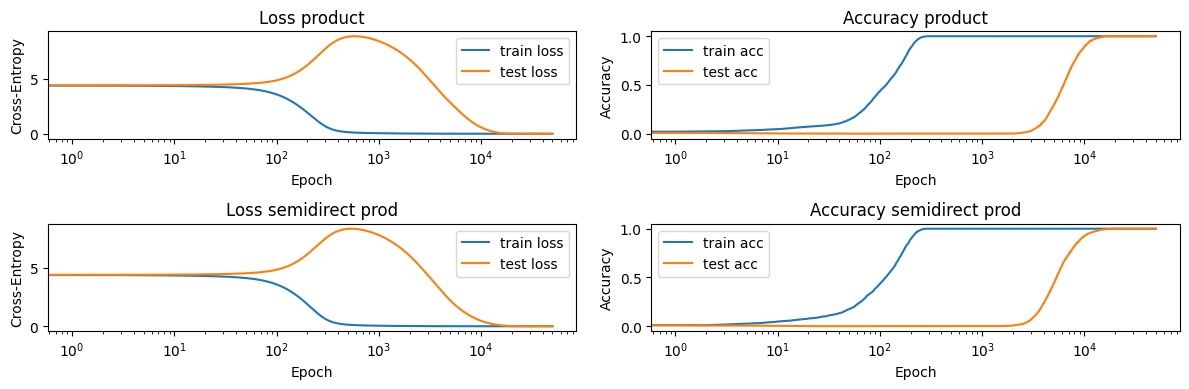

In [14]:



train_losses1_cpu = measure_prod['train_loss'].detach().cpu()
test_losses1_cpu = measure_prod['test_losses'].detach().cpu()
train_accs1_cpu = measure_prod['train_accs'].detach().cpu()
test_accs1_cpu = measure_prod['test_accs'].detach().cpu()

train_losses2_cpu = measure_semidir['train_loss'].detach().cpu()
test_losses2_cpu = measure_semidir['test_losses'].detach().cpu()
train_accs2_cpu = measure_semidir['train_accs'].detach().cpu()
test_accs2_cpu = measure_semidir['test_accs'].detach().cpu()

epochs_cpu = torch.arange(len(train_losses1_cpu))
fig, axes = plt.subplots(2, 2, figsize=(12, 4))

axes[0,0].set_xscale('log')
axes[0,0].plot(epochs_cpu, train_losses1_cpu, label="train loss")
axes[0,0].plot(epochs_cpu, test_losses1_cpu, label="test loss")
axes[0,0].set_title("Loss product")
axes[0,0].set_xlabel("Epoch")
axes[0,0].set_ylabel("Cross-Entropy")
axes[0,0].legend()

axes[0,1].set_xscale('log')
axes[0,1].plot(epochs_cpu, train_accs1_cpu, label="train acc")
axes[0,1].plot(epochs_cpu, test_accs1_cpu, label="test acc")
axes[0,1].set_title("Accuracy product")
axes[0,1].set_xlabel("Epoch")
axes[0,1].set_ylabel("Accuracy")
axes[0,1].legend()


axes[1,0].set_xscale('log')
axes[1,0].plot(epochs_cpu, train_losses2_cpu, label="train loss")
axes[1,0].plot(epochs_cpu, test_losses2_cpu, label="test loss")
axes[1,0].set_title("Loss semidirect prod")
axes[1,0].set_xlabel("Epoch")
axes[1,0].set_ylabel("Cross-Entropy")
axes[1,0].legend()

axes[1,1].set_xscale('log')
axes[1,1].plot(epochs_cpu, train_accs2_cpu, label="train acc")
axes[1,1].plot(epochs_cpu, test_accs2_cpu, label="test acc")
axes[1,1].set_title("Accuracy semidirect prod")
axes[1,1].set_xlabel("Epoch")
axes[1,1].set_ylabel("Accuracy")
axes[1,1].legend()

plt.tight_layout()
plt.show()


In [18]:
prod_results = train_group(kind="direct")
semi_results = train_group(kind="semidirect")

direct     | Epoch   2000/50000 | train_loss=0.020150 | test_loss=7.343740 | test_full=0.001487 | test_Cp=0.008178 | test_C2=0.626022 | test_Cp_b0=0.010304 | test_Cp_b1=0.006009
direct     | Epoch   4000/50000 | train_loss=0.005598 | test_loss=4.618656 | test_full=0.060223 | test_Cp=0.064436 | test_C2=0.808426 | test_Cp_b0=0.079490 | test_Cp_b1=0.049074
direct     | Epoch   6000/50000 | train_loss=0.001836 | test_loss=2.559891 | test_full=0.347212 | test_Cp=0.349938 | test_C2=0.896406 | test_Cp_b0=0.374387 | test_Cp_b1=0.324988
direct     | Epoch   8000/50000 | train_loss=0.000658 | test_loss=1.326038 | test_full=0.674845 | test_Cp=0.676332 | test_C2=0.956134 | test_Cp_b0=0.687439 | test_Cp_b1=0.664998
direct     | Epoch  10000/50000 | train_loss=0.000246 | test_loss=0.677187 | test_full=0.866915 | test_Cp=0.867162 | test_C2=0.979182 | test_Cp_b0=0.873896 | test_Cp_b1=0.860290
direct     | Epoch  12000/50000 | train_loss=0.000094 | test_loss=0.331329 | test_full=0.946221 | test_Cp=0.94

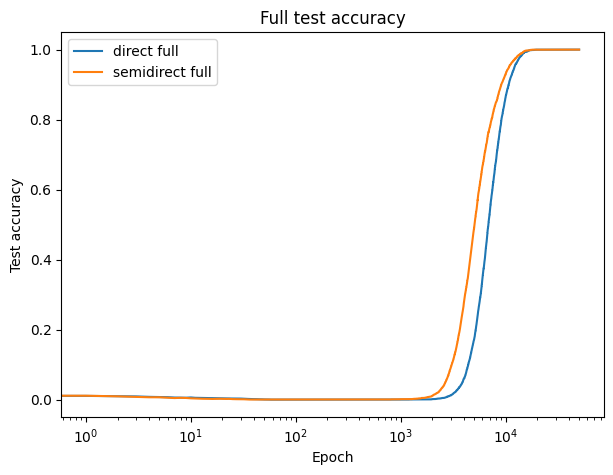

In [19]:
plt.figure(figsize=(7, 5))

plt.plot(prod_results["test_full_accs"].detach().cpu(), label="direct full")
plt.plot(semi_results["test_full_accs"].detach().cpu(), label="semidirect full")

plt.xscale("log")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.legend()
plt.title("Full test accuracy")
plt.show()

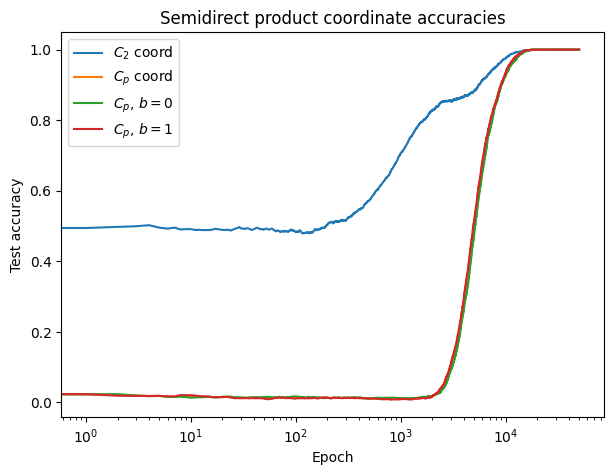

In [20]:
plt.figure(figsize=(7, 5))

plt.plot(semi_results["test_C2_accs"].detach().cpu(), label=r"$C_2$ coord")
plt.plot(semi_results["test_Cp_accs"].detach().cpu(), label=r"$C_p$ coord")
plt.plot(semi_results["test_Cp_accs_b0"].detach().cpu(), label=r"$C_p$, $b=0$")
plt.plot(semi_results["test_Cp_accs_b1"].detach().cpu(), label=r"$C_p$, $b=1$")

plt.xscale("log")
plt.xlabel("Epoch")
plt.ylabel("Test accuracy")
plt.legend()
plt.title("Semidirect product coordinate accuracies")
plt.show()

The $\mathbb{Z}_2$ rule seems to easy to distinguish. I should try a different one, maybe with $\mathbb{Z}_5$. Below is code for generating data in $\mathbb{Z}_p\times \mathbb{Z}_m$ and $\mathbb{Z}_p\rtimes \mathbb{Z}_m$.

In [2]:
#function that constructs the product in Zp x Zm
def direct_Cp_Cm_labels(X_pairs, p: int, m: int):
    g = X_pairs[:, 0]
    h = X_pairs[:, 1]

    a = g % p
    b = g // p

    ap = h % p
    bp = h // p

    c = (a + ap) % p
    d = (b + bp) % m

    Y = c + p * d
    return Y

In [3]:
#function that constructs the product in Zp <- Zm
def semidirect_Cp_Cm_labels(X_pairs, p: int, m: int, r: int):
    g = X_pairs[:, 0]
    h = X_pairs[:, 1]

    a = g % p
    b = g // p

    ap = h % p
    bp = h // p

    powers = torch.tensor(
        [pow(r, k, p) for k in range(m)],
        device=X_pairs.device,
        dtype=torch.long
    )

    factor = powers[b]

    c = (a + factor * ap) % p
    d = (b + bp) % m

    Y = c + p * d
    return Y

In [4]:
def find_element_of_order(p: int, m: int):
    """
    Find r in F_p^* with order exactly m.
    Requires m | p-1.
    """
    if (p - 1) % m != 0:
        raise ValueError(f"Need m | p-1 for this semidirect product. Got p={p}, m={m}.")

    for r in range(2, p):
        if pow(r, m, p) == 1:
            has_smaller_order = False
            for k in range(1, m):
                if pow(r, k, p) == 1:
                    has_smaller_order = True
                    break
            if not has_smaller_order:
                return r

    raise ValueError(f"No element of order {m} found modulo {p}.")

In [5]:
#encode data as g=q_p +p q_m, where q_p is in Zp and q_m is in Zm
def data_create_Cp_Cm(
    p: int,
    m: int,
    frac: float,
    device,
    pair_seed: int = None,
    kind: str = "direct",
    r: int = None,
):
    """
    kind = "direct" or "semidirect"

    Direct:
        C_p x C_m

    Semidirect:
        C_p ⋊ C_m with action a -> r^b a.
    """

    assert kind in ["direct", "semidirect"]

    group_size = p * m

    X_pairs = torch.cartesian_prod(
        torch.arange(group_size, device=device),
        torch.arange(group_size, device=device)
    )

    if kind == "direct":
        Y = direct_Cp_Cm_labels(X_pairs, p, m)

    elif kind == "semidirect":
        if r is None:
            r = find_element_of_order(p, m)

        Y = semidirect_Cp_Cm_labels(X_pairs, p, m, r)

    # One-hot encode two group elements
    X = F.one_hot(X_pairs, num_classes=group_size).float()

    # Flatten from [n_examples, 2, group_size] to [n_examples, 2 * group_size]
    X = X.reshape(X.shape[0], -1)

    n = X.shape[0]
    n_train = int(frac * n)

    if pair_seed is None:
        perm = torch.randperm(n, device=device)
    else:
        gen = torch.Generator(device=device).manual_seed(pair_seed)
        perm = torch.randperm(n, generator=gen, device=device)

    train_idx = perm[:n_train]
    test_idx = perm[n_train:]

    return {
        "kind": kind,
        "p": p,
        "m": m,
        "r": r if kind == "semidirect" else None,

        "X_pairs": X_pairs,
        "Y": Y,

        "X_train": X[train_idx],
        "Y_train": Y[train_idx],

        "X_test": X[test_idx],
        "Y_test": Y[test_idx],

        "pairs_train": X_pairs[train_idx],
        "pairs_test": X_pairs[test_idx],
    }

In [15]:
p = 31
m=3
frac = 0.4
hid_size = 1000
n_epochs = 100000

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

In [8]:
@torch.no_grad()
def group_coordinate_metrics_Cp_Cm(logits, pairs, p: int, m: int, kind="direct", r=None):
    """
    logits: [batch, p*m]
    pairs:  [batch, 2], each entry is a token g = a + p*b
    """

    pred = logits.argmax(dim=1)

    pred_c = pred % p
    pred_d = pred // p

    g = pairs[:, 0]
    h = pairs[:, 1]

    a = g % p
    b = g // p

    ap = h % p
    bp = h // p

    if kind == "direct":
        factor = torch.ones_like(b)

    else:
        if r is None:
            r = find_element_of_order(p, m)

        powers = torch.tensor(
            [pow(r, k, p) for k in range(m)],
            device=pairs.device,
            dtype=torch.long
        )
        factor = powers[b]

    true_c = (a + factor * ap) % p
    true_d = (b + bp) % m
    true_y = true_c + p * true_d

    full_acc = (pred == true_y).float().mean()
    Cp_acc = (pred_c == true_c).float().mean()
    Cm_acc = (pred_d == true_d).float().mean()

    Cp_acc_by_b = []
    full_acc_by_b = []

    for j in range(m):
        mask = (b == j)

        Cp_acc_j = (pred_c[mask] == true_c[mask]).float().mean()
        full_acc_j = (pred[mask] == true_y[mask]).float().mean()

        Cp_acc_by_b.append(Cp_acc_j)
        full_acc_by_b.append(full_acc_j)

    return {
        "full_acc": full_acc,
        "Cp_acc": Cp_acc,
        "Cm_acc": Cm_acc,
        "Cp_acc_by_b": Cp_acc_by_b,
        "full_acc_by_b": full_acc_by_b,
    }

In [9]:
def train_Cp_Cm(kind="direct"):

    group_size = p * m

    model = MLP(
        in_size=2 * group_size,
        hid_size=hid_size,
        out_size=group_size
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.5)

    train_losses = torch.empty(n_epochs, device=device)
    test_losses = torch.empty(n_epochs, device=device)

    train_full_accs = torch.empty(n_epochs, device=device)
    test_full_accs = torch.empty(n_epochs, device=device)

    train_Cp_accs = torch.empty(n_epochs, device=device)
    test_Cp_accs = torch.empty(n_epochs, device=device)

    train_Cm_accs = torch.empty(n_epochs, device=device)
    test_Cm_accs = torch.empty(n_epochs, device=device)

    train_Cp_accs_by_b = torch.empty(n_epochs, m, device=device)
    test_Cp_accs_by_b = torch.empty(n_epochs, m, device=device)

    data = data_create_Cp_Cm(
        p=p,
        m=m,
        frac=frac,
        device=device,
        pair_seed=420,
        kind=kind,
    )

    r = data["r"]

    X_train = data["X_train"].float()
    Y_train = data["Y_train"]

    X_test = data["X_test"].float()
    Y_test = data["Y_test"]

    pairs_train = data["pairs_train"]
    pairs_test = data["pairs_test"]

    for epoch in range(n_epochs):
        model.train()

        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, Y_train)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_logits = model(X_train)
            test_logits = model(X_test)

            train_loss = criterion(train_logits, Y_train)
            test_loss = criterion(test_logits, Y_test)

            train_metrics = group_coordinate_metrics_Cp_Cm(
                train_logits,
                pairs_train,
                p=p,
                m=m,
                kind=kind,
                r=r,
            )

            test_metrics = group_coordinate_metrics_Cp_Cm(
                test_logits,
                pairs_test,
                p=p,
                m=m,
                kind=kind,
                r=r,
            )

        train_losses[epoch] = train_loss
        test_losses[epoch] = test_loss

        train_full_accs[epoch] = train_metrics["full_acc"]
        test_full_accs[epoch] = test_metrics["full_acc"]

        train_Cp_accs[epoch] = train_metrics["Cp_acc"]
        test_Cp_accs[epoch] = test_metrics["Cp_acc"]

        train_Cm_accs[epoch] = train_metrics["Cm_acc"]
        test_Cm_accs[epoch] = test_metrics["Cm_acc"]

        train_Cp_accs_by_b[epoch] = torch.stack(train_metrics["Cp_acc_by_b"])
        test_Cp_accs_by_b[epoch] = torch.stack(test_metrics["Cp_acc_by_b"])

        if (epoch + 1) % 2000 == 0:
            print(
                f"{kind:10s} | "
                f"Epoch {epoch+1:6d}/{n_epochs} | "
                f"train_loss={train_loss.item():.6f} | "
                f"test_loss={test_loss.item():.6f} | "
                f"test_full={test_metrics['full_acc'].item():.6f} | "
                f"test_Cp={test_metrics['Cp_acc'].item():.6f} | "
                f"test_Cm={test_metrics['Cm_acc'].item():.6f}"
            )

    return {
        "model": model,
        "data": data,

        "train_losses": train_losses,
        "test_losses": test_losses,

        "train_full_accs": train_full_accs,
        "test_full_accs": test_full_accs,

        "train_Cp_accs": train_Cp_accs,
        "test_Cp_accs": test_Cp_accs,

        "train_Cm_accs": train_Cm_accs,
        "test_Cm_accs": test_Cm_accs,

        "train_Cp_accs_by_b": train_Cp_accs_by_b,
        "test_Cp_accs_by_b": test_Cp_accs_by_b,
    }

In [16]:
semi_results = train_Cp_Cm(kind="semidirect")

semidirect | Epoch   2000/100000 | train_loss=0.008002 | test_loss=8.879522 | test_full=0.000000 | test_Cp=0.015414 | test_Cm=0.342967
semidirect | Epoch   4000/100000 | train_loss=0.002347 | test_loss=8.505429 | test_full=0.000000 | test_Cp=0.011946 | test_Cm=0.446435
semidirect | Epoch   6000/100000 | train_loss=0.000810 | test_loss=8.177280 | test_full=0.000000 | test_Cp=0.007514 | test_Cm=0.642389
semidirect | Epoch   8000/100000 | train_loss=0.000301 | test_loss=7.987568 | test_full=0.000000 | test_Cp=0.005588 | test_Cm=0.764933
semidirect | Epoch  10000/100000 | train_loss=0.000116 | test_loss=7.922372 | test_full=0.000000 | test_Cp=0.006166 | test_Cm=0.771676
semidirect | Epoch  12000/100000 | train_loss=0.000047 | test_loss=7.785354 | test_full=0.000193 | test_Cp=0.005973 | test_Cm=0.764547
semidirect | Epoch  14000/100000 | train_loss=0.000021 | test_loss=7.526513 | test_full=0.000385 | test_Cp=0.005588 | test_Cm=0.769942
semidirect | Epoch  16000/100000 | train_loss=0.000011 

In [24]:
dir_results = train_Cp_Cm(kind="direct")

direct     | Epoch   2000/20000 | train_loss=0.011448 | test_loss=4.872878 | test_full=0.058758 | test_Cp=0.080749 | test_Cm=0.252445
direct     | Epoch   4000/20000 | train_loss=0.002857 | test_loss=1.000160 | test_full=0.860701 | test_Cp=0.864932 | test_Cm=0.889074
direct     | Epoch   6000/20000 | train_loss=0.000932 | test_loss=0.227275 | test_full=0.991537 | test_Cp=0.992300 | test_Cm=0.993410
direct     | Epoch   8000/20000 | train_loss=0.000331 | test_loss=0.066417 | test_full=0.999584 | test_Cp=0.999722 | test_Cm=0.999722
direct     | Epoch  10000/20000 | train_loss=0.000124 | test_loss=0.021847 | test_full=1.000000 | test_Cp=1.000000 | test_Cm=1.000000
direct     | Epoch  12000/20000 | train_loss=0.000049 | test_loss=0.007440 | test_full=1.000000 | test_Cp=1.000000 | test_Cm=1.000000
direct     | Epoch  14000/20000 | train_loss=0.000021 | test_loss=0.002565 | test_full=1.000000 | test_Cp=1.000000 | test_Cm=1.000000
direct     | Epoch  16000/20000 | train_loss=0.000011 | test_l

Below is $\mathbb{Z}_2$. 200 neurons

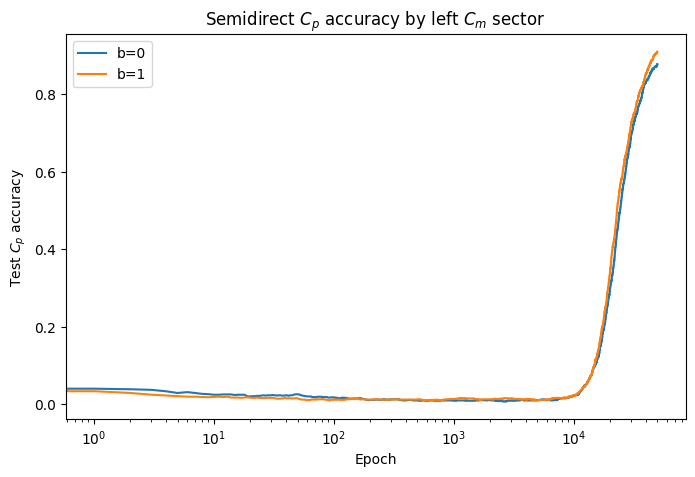

In [11]:
plt.figure(figsize=(8, 5))

for j in range(m):
    plt.plot(
        semi_results["test_Cp_accs_by_b"][:, j].detach().cpu(),
        label=f"b={j}"
    )

plt.xscale("log")
plt.xlabel("Epoch")
plt.ylabel(r"Test $C_p$ accuracy")
plt.title(r"Semidirect $C_p$ accuracy by left $C_m$ sector")
plt.legend()
plt.show()

Below is $\mathbb{Z}_5$. 600 neurons

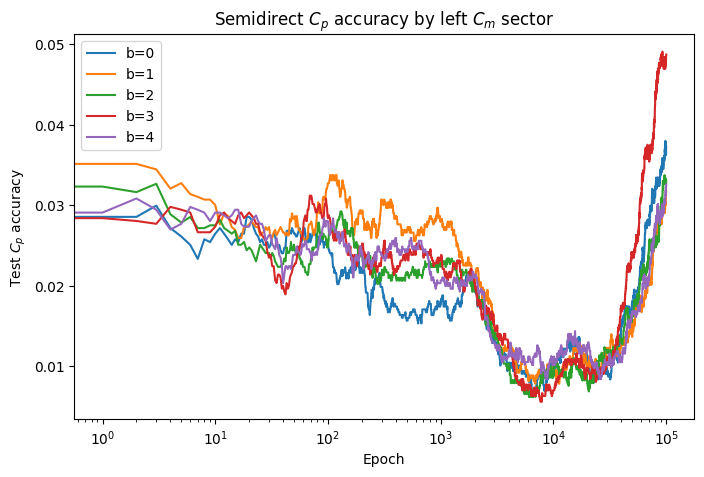

In [ ]:
plt.figure(figsize=(8, 5))

for j in range(m):
    plt.plot(
        semi_results["test_Cp_accs_by_b"][:, j].detach().cpu(),
        label=f"b={j}"
    )

plt.xscale("log")
plt.xlabel("Epoch")
plt.ylabel(r"Test $C_p$ accuracy")
plt.title(r"Semidirect $C_p$ accuracy by left $C_m$ sector")
plt.legend()
plt.show()

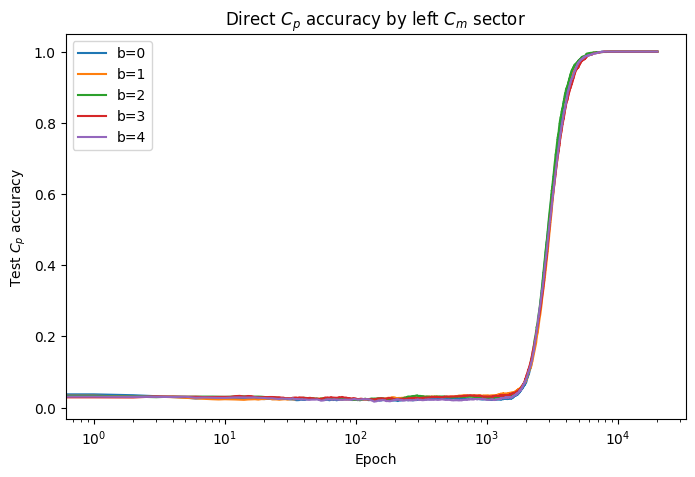

In [25]:
plt.figure(figsize=(8, 5))

for j in range(m):
    plt.plot(
        dir_results["test_Cp_accs_by_b"][:, j].detach().cpu(),
        label=f"b={j}"
    )

plt.xscale("log")
plt.xlabel("Epoch")
plt.ylabel(r"Test $C_p$ accuracy")
plt.title(r"Direct $C_p$ accuracy by left $C_m$ sector")
plt.legend()
plt.show()

$\mathbb{Z}_3$

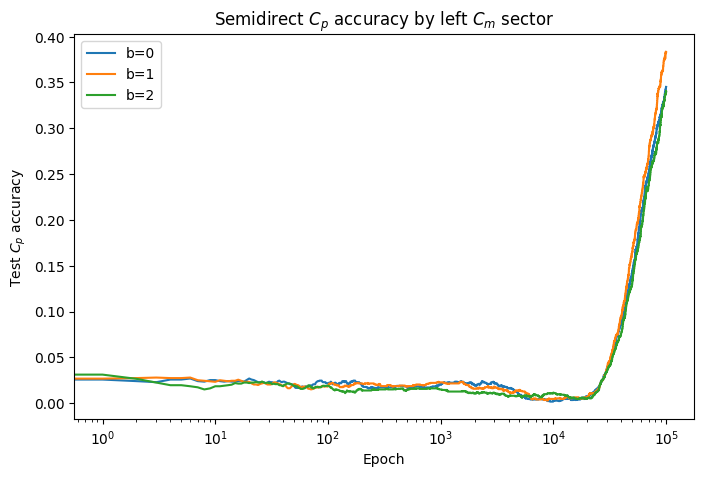

In [17]:
plt.figure(figsize=(8, 5))

for j in range(m):
    plt.plot(
        semi_results["test_Cp_accs_by_b"][:, j].detach().cpu(),
        label=f"b={j}"
    )

plt.xscale("log")
plt.xlabel("Epoch")
plt.ylabel(r"Test $C_p$ accuracy")
plt.title(r"Semidirect $C_p$ accuracy by left $C_m$ sector")
plt.legend()
plt.show()